# Figure 3C 3D V2
Compare DS R1-0528, V3 and expert models, final version

In [ ]:
import os
from pathlib import Path
import json
import pandas as pd
import numpy as np
import math
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick 
from plot import *

In [2]:
# load data
dir = Path('/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_val/responses')
file_paths = [
    'long_prompt_v3/100genes/results_cleaned_v2.csv',
    'short_prompt_v3/100genes/results_cleaned_v2.csv',
    'short_prompt_r1_0528/100genes/results_cleaned_v2.csv',
    'long_prompt_r1_0528//100genes/results_cleaned_v2.csv'
]

In [3]:
v3_long, v3, r1_0528, r1_0528_long = (pd.read_csv(dir/file) for file in file_paths)

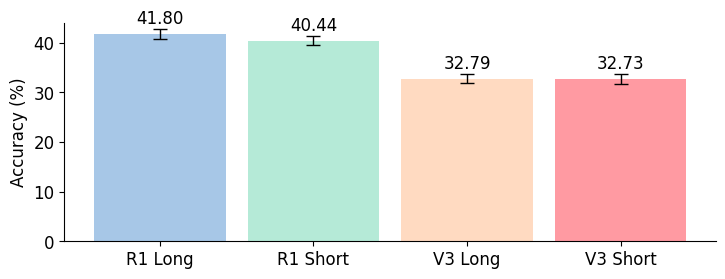

In [4]:
# get accuracies after removing unmatched cells
accuracies = [float(df.iloc[-10,2]) for df in [r1_0528_long, r1_0528, v3_long, v3]]
upper_error_bars = [float(df.iloc[-5, 2]) - float(df.iloc[-10, 2]) for df in [r1_0528_long, r1_0528, v3_long, v3]]
lower_error_bars = [float(df.iloc[-10, 2])-float(df.iloc[-6, 2]) for df in [r1_0528_long, r1_0528, v3_long, v3]]
models = ['R1 Long', 'R1 Short', 'V3 Long', 'V3 Short']
plotter = MetricPlotter(bar_width = 0.3, annotation_digits=2, y_lim_lower = 0, y_lim_upper=44, figure_height=3)
plotter.group_gap = 0.05
plotter.text_margin = 0.001
plotter.display_axes_borders='xy'
plotter.colors = ['#A7C7E7', '#B5EAD7', '#FFDAC1', '#FF9AA2', '#C7CEEA']
# plotter.rotation = 30
plotter.bar_fontsize = 12
plotter.x_label_fontsize = 12
plotter.y_label_fontsize=12
plotter.x_tick_fontsize=12
plotter.y_tick_fontsize=12
plotter.barplot(models ,np.array(accuracies), 
             x_label="", y_label="Accuracy", 
             err_low=lower_error_bars, err_high=upper_error_bars
             # title="LLMs' Performance for Clusters"
             )
# 1 2.79 3.77

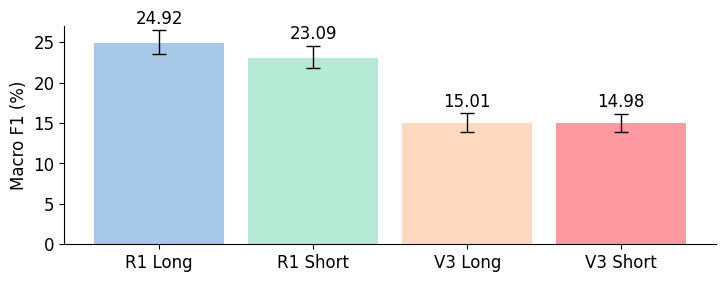

In [7]:
models = ['R1 Long', 'R1 Short', 'V3 Long', 'V3 Short']
macro_f1 = [float(df.iloc[-9,2]) for df in [r1_0528_long, r1_0528, v3_long, v3]]
upper_error_bars = [float(df.iloc[-3, 2]) - float(df.iloc[-9, 2]) for df in [r1_0528_long, r1_0528, v3_long, v3]]
lower_error_bars = [float(df.iloc[-9, 2])-float(df.iloc[-4, 2]) for df in [r1_0528_long, r1_0528, v3_long, v3]]
plotter = MetricPlotter(bar_width = 0.3, annotation_digits=2, y_lim_lower = 0, y_lim_upper=27, figure_height=3)
plotter.group_gap = 0.055
plotter.text_margin = 0.001
plotter.display_axes_borders='xy'
plotter.colors = ['#A7C7E7', '#B5EAD7', '#FFDAC1', '#FF9AA2', '#C7CEEA']
# plotter.rotation = 30
plotter.bar_fontsize = 12
plotter.x_label_fontsize = 12
plotter.y_label_fontsize=12
plotter.x_tick_fontsize=12
plotter.y_tick_fontsize=12
plotter.barplot(models ,np.array(macro_f1), 
             x_label="", y_label="Macro F1", 
             err_low=lower_error_bars, err_high=upper_error_bars)
# 1 2.79 4.77

In [39]:
# sctab test datasets
file_paths_test = [
    '/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_test/responses/scTab/results_cleaned_v2.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_test/responses/scGPT/results_cleaned_v2.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_test/responses/long_prompt_r1_0528/500genes_scGPTClassifier/results_cleaned_v2.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_test/responses/long_prompt_r1_0528/500genes_scTabClassifier/results_cleaned_v2.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_test/responses/long_prompt_r1_0528/500genes/results_cleaned_v2.csv'
]
# cellxgene 8 datasets
file_paths_8d = [
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/scTab/results_cleaned_v2.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/scGPT/results_cleaned_v2.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/short_prompt_r1/100genes_scGPTClassifier/results_cleaned_v2.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/short_prompt_r1/100genes_scTabClassifier/results_cleaned_v2.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/short_prompt_r1/100genes/results_cleaned_v2.csv'
]
file_paths_random = [
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/scTab/results_cleaned_v2.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/scGPT/results_cleaned_v2.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/short_prompt_r1/100genes_scTabClassifier/results_cleaned_v2.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/short_prompt_r1/100genes/results_cleaned_v2.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/short_prompt_r1/100genes_scGPTClassifier/results_cleaned_v2.csv',
]


In [40]:
# cellxgene random sampled sctab test data
sctab, scgpt, r1_scgpt_cls, r1_sctab_cls, r1 = (pd.read_csv(file) for file in file_paths_test)
c2s = pd.read_csv('/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_test/responses/c2s_scale/200genes/prediction_results/results_cleaned_v2.csv')

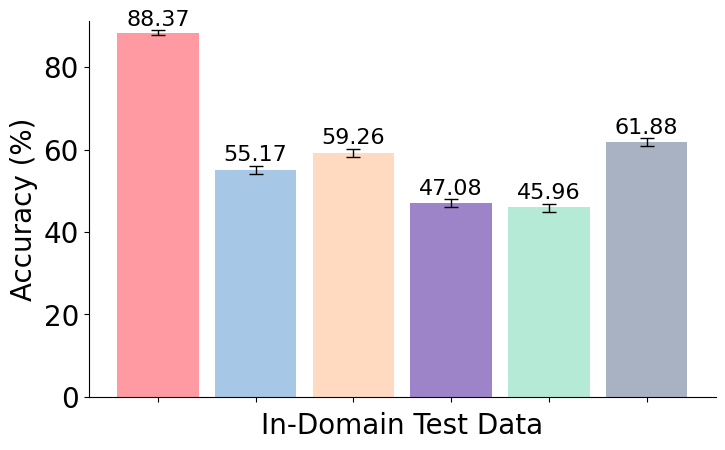

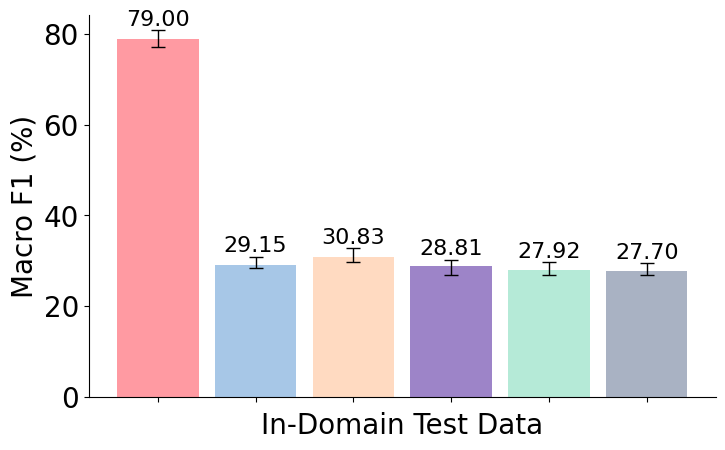

In [43]:
# 3D, models on in-domain scTab test dataset
accuracies = [float(df.iloc[-10,2]) for df in [sctab, r1_scgpt_cls, r1_sctab_cls, scgpt, r1, c2s]]
upper_error_bars = [float(df.iloc[-5, 2]) - float(df.iloc[-10, 2]) for df in [sctab, r1_scgpt_cls, r1_sctab_cls, scgpt, r1, c2s]]
lower_error_bars = [float(df.iloc[-10, 2])-float(df.iloc[-6, 2]) for df in [sctab, r1_scgpt_cls, r1_sctab_cls, scgpt, r1, c2s]]
models = ['']*6
plotter = MetricPlotter(bar_width = 0.25, annotation_digits=2, y_lim_lower = 0)
plotter.group_gap = 0.05
plotter.figure_height = 5
plotter.text_margin = 0.001
plotter.display_axes_borders='xy'
plotter.colors = ['#FF9AA2','#A7C7E7','#FFDAC1','#9D84C8','#B5EAD7', '#A9B2C3']
# plotter.rotation = 30
plotter.bar_fontsize = 16
plotter.x_label_fontsize = 20
plotter.y_label_fontsize=20
plotter.x_tick_fontsize=20
plotter.y_tick_fontsize=20
plotter.barplot(models ,np.array(accuracies), 
             x_label="In-Domain Test Data", y_label="Accuracy", 
             err_low=lower_error_bars, err_high=upper_error_bars
             # title="LLMs' Performance for Clusters"
             )

Macro_F1 = [float(df.iloc[-9,2]) for df in [sctab, r1_scgpt_cls, r1_sctab_cls, scgpt, r1, c2s]]
upper_error_bars = [float(df.iloc[-3, 2]) - float(df.iloc[-9, 2]) for df in [sctab, r1_scgpt_cls, r1_sctab_cls, scgpt, r1, c2s]]
lower_error_bars = [float(df.iloc[-9, 2])-float(df.iloc[-4, 2]) for df in [sctab, r1_scgpt_cls, r1_sctab_cls, scgpt, r1, c2s]]
models = ['']*6
plotter = MetricPlotter(bar_width = 0.25, annotation_digits=2, y_lim_lower = 0)
plotter.group_gap = 0.05
plotter.figure_height = 5
plotter.text_margin = 0.001
plotter.display_axes_borders='xy'
plotter.colors = ['#FF9AA2','#A7C7E7','#FFDAC1','#9D84C8','#B5EAD7', '#A9B2C3']
# plotter.rotation = 30
plotter.bar_fontsize = 16
plotter.x_label_fontsize = 20
plotter.y_label_fontsize=20
plotter.x_tick_fontsize=20
plotter.y_tick_fontsize=20
plotter.barplot(models ,np.array(Macro_F1), 
             x_label="In-Domain Test Data", y_label="Macro F1", 
             err_low=lower_error_bars, err_high=upper_error_bars
             # title="LLMs' Performance for Clusters"
             )
# 1 5.57 3.77
# 1 5.57 4.77